Preferencias ordenadas de hospitales:
  Hospital A: ['Ana', 'Sofia', 'Luis']
  Hospital B: ['Luis', 'Ana', 'Sofia']
  Hospital C: ['Sofia', 'Ana', 'Luis']

Preferencias ordenadas de alumnos:
  Ana: ['Hospital A', 'Hospital B', 'Hospital C']
  Luis: ['Hospital B', 'Hospital C', 'Hospital A']
  Sofia: ['Hospital C', 'Hospital A', 'Hospital B']

Emparejamientos finales:
  Hospital A - Ana
  Hospital B - Luis
  Hospital C - Sofia


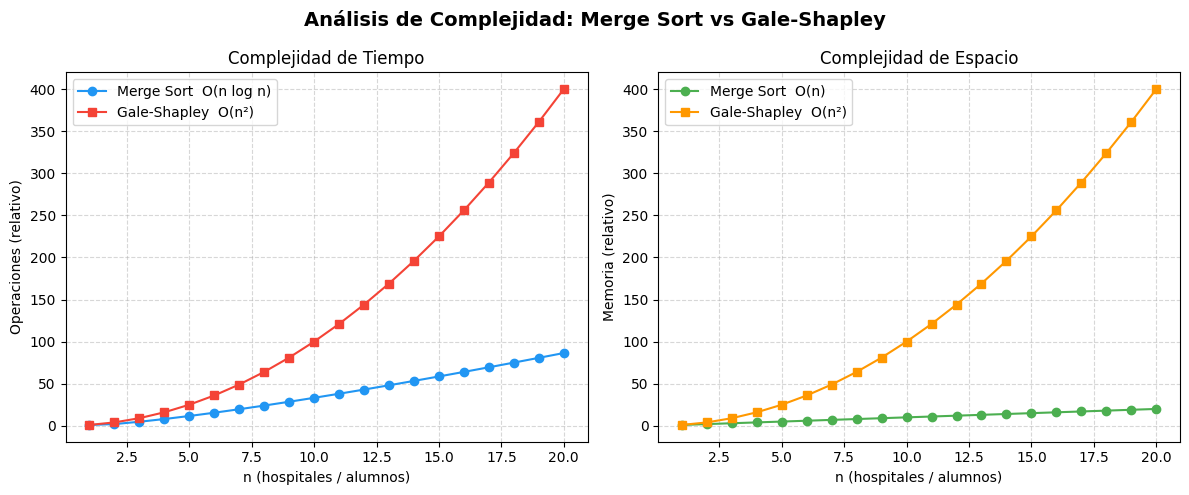

In [2]:
def merge_sort(lista):
    if len(lista) <= 1:
        return lista
    mid = len(lista) // 2
    izq = merge_sort(lista[:mid])
    der = merge_sort(lista[mid:])
    return merge(izq, der)

def merge(izq, der):
    resultado = []
    i = j = 0
    while i < len(izq) and j < len(der):
        if izq[i][1] >= der[j][1]:
            resultado.append(izq[i])
            i += 1
        else:
            resultado.append(der[j])
            j += 1
    resultado.extend(izq[i:])
    resultado.extend(der[j:])
    return resultado

def ordenar_preferencias(preferencias):
    ordenadas = {}
    for entidad, lista in preferencias.items():
        ordenadas[entidad] = merge_sort(lista)
    return ordenadas

def gale_shapley(hospitales_ord, alumnos_ord):
    hospital_a_alumno = {}
    alumno_a_hospital = {}
    hospitales_libres = list(hospitales_ord.keys())
    siguiente_propuesta = {h: 0 for h in hospitales_ord}
    ranking_alumno = {}
    for alumno, lista in alumnos_ord.items():
        ranking_alumno[alumno] = {hospital: i for i, (hospital, _) in enumerate(lista)}

    while hospitales_libres:
        hospital = hospitales_libres[0]
        idx = siguiente_propuesta[hospital]
        alumno, _ = hospitales_ord[hospital][idx]
        siguiente_propuesta[hospital] += 1

        if alumno not in alumno_a_hospital:
            alumno_a_hospital[alumno] = hospital
            hospital_a_alumno[hospital] = alumno
            hospitales_libres.pop(0)
        else:
            actual = alumno_a_hospital[alumno]
            if ranking_alumno[alumno][hospital] < ranking_alumno[alumno][actual]:
                hospital_a_alumno[actual] = None
                hospitales_libres.append(actual)
                alumno_a_hospital[alumno] = hospital
                hospital_a_alumno[hospital] = alumno
                hospitales_libres.pop(0)

    return hospital_a_alumno

def analisis_tiempo_espacio(n_max=20):
    import matplotlib.pyplot as plt
    import math

    ns = list(range(1, n_max + 1))
    merge_sort_t  = [n * math.log2(n) if n > 1 else 1 for n in ns]
    gale_shapley_t = [n ** 2 for n in ns]
    merge_sort_e  = [n for n in ns]
    gale_shapley_e = [n ** 2 for n in ns]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Análisis de Complejidad: Merge Sort vs Gale-Shapley", fontsize=14, fontweight="bold")

    axes[0].plot(ns, merge_sort_t,   marker="o", label="Merge Sort  O(n log n)", color="#2196F3")
    axes[0].plot(ns, gale_shapley_t, marker="s", label="Gale-Shapley  O(n²)",    color="#F44336")
    axes[0].set_title("Complejidad de Tiempo")
    axes[0].set_xlabel("n (hospitales / alumnos)")
    axes[0].set_ylabel("Operaciones (relativo)")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(ns, merge_sort_e,   marker="o", label="Merge Sort  O(n)",  color="#4CAF50")
    axes[1].plot(ns, gale_shapley_e, marker="s", label="Gale-Shapley  O(n²)", color="#FF9800")
    axes[1].set_title("Complejidad de Espacio")
    axes[1].set_xlabel("n (hospitales / alumnos)")
    axes[1].set_ylabel("Memoria (relativo)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

hospitales = {
    "Hospital A": [("Ana", 90), ("Luis", 70), ("Sofia", 85)],
    "Hospital B": [("Ana", 80), ("Luis", 95), ("Sofia", 60)],
    "Hospital C": [("Ana", 75), ("Luis", 65), ("Sofia", 100)]
}

alumnos = {
    "Ana":   [("Hospital A", 95), ("Hospital B", 80), ("Hospital C", 70)],
    "Luis":  [("Hospital A", 60), ("Hospital B", 100), ("Hospital C", 75)],
    "Sofia": [("Hospital A", 85), ("Hospital B", 65), ("Hospital C", 90)]
}

hospitales_ord = ordenar_preferencias(hospitales)
alumnos_ord    = ordenar_preferencias(alumnos)

print("Preferencias ordenadas de hospitales:")
for h, lista in hospitales_ord.items():
    print(f"  {h}: {[a for a, _ in lista]}")

print("\nPreferencias ordenadas de alumnos:")
for a, lista in alumnos_ord.items():
    print(f"  {a}: {[h for h, _ in lista]}")

emparejamientos = gale_shapley(hospitales_ord, alumnos_ord)

print("\nEmparejamientos finales:")
for hospital, alumno in emparejamientos.items():
    print(f"  {hospital} - {alumno}")

analisis_tiempo_espacio()